# 01 — Initial EDA

Entender el negocio: estructura del dataset, missingness, patrones temporales por tienda/categoría/región.

Periodo: 2023-01-01 → 2024-02-29. 80 tiendas × 6 categorías × 425 días.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from retail_ops_forecasting.config import load_config
from retail_ops_forecasting.data import load_transactions, load_stores, load_calendar, build_merged
sns.set_style('whitegrid')
cfg = load_config(ROOT / 'configs' / 'config.yaml')


## Carga y shape

In [2]:
tx = load_transactions(cfg.paths.raw_dir / cfg.data.transactions_file)
st = load_stores(cfg.paths.raw_dir / cfg.data.stores_file)
cal = load_calendar(cfg.paths.raw_dir / cfg.data.calendar_file)
print('transactions:', tx.shape, '| stores:', st.shape, '| calendar:', cal.shape)
tx.head(3)

transactions: (203958, 13) | stores: (80, 9) | calendar: (425, 16)


,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal
0,2023-01-01,STR_001,Abarrotes,833,<NA>,326,244732.98,NaN,101822.79,2299.0,NaN,0,NaN
1,2023-01-02,STR_001,Abarrotes,1298,750,548,373235.09,222834.25,150400.84,3011.0,287.55,0,NaN
2,2023-01-03,STR_001,Abarrotes,1614,931,683,404249.92,239802.59,164447.33,3652.0,250.46,0,1546.0


## Cobertura: tiendas × categorías × días

In [3]:
print('stores:', tx.store_id.nunique(), '| categories:', tx.category.nunique(), '| days:', tx.date.nunique())
rows_expected = tx.store_id.nunique() * tx.category.nunique() * tx.date.nunique()
print(f'rows expected = {rows_expected:,}; observed = {len(tx):,}; ratio = {len(tx)/rows_expected:.4f}')

stores: 80 | categories: 6 | days: 425
rows expected = 204,000; observed = 203,958; ratio = 0.9998


## Missingness por columna

In [4]:
miss = tx.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
(miss / len(tx) * 100).round(3).to_frame('pct_missing')

,pct_missing
cash_transactions,5.944
amount_cash,5.944
units_sold,3.000
avg_ticket,2.390
replenishment_signal,0.471


Las columnas con datos faltantes son consistentes con el diccionario: `cash_transactions` y `amount_cash` (~5.9%) por fallas de POS; `units_sold` (3%); `avg_ticket` (~2.4%); `replenishment_signal` (0.47% — sólo últimos días).

## Distribución de `total_transactions`

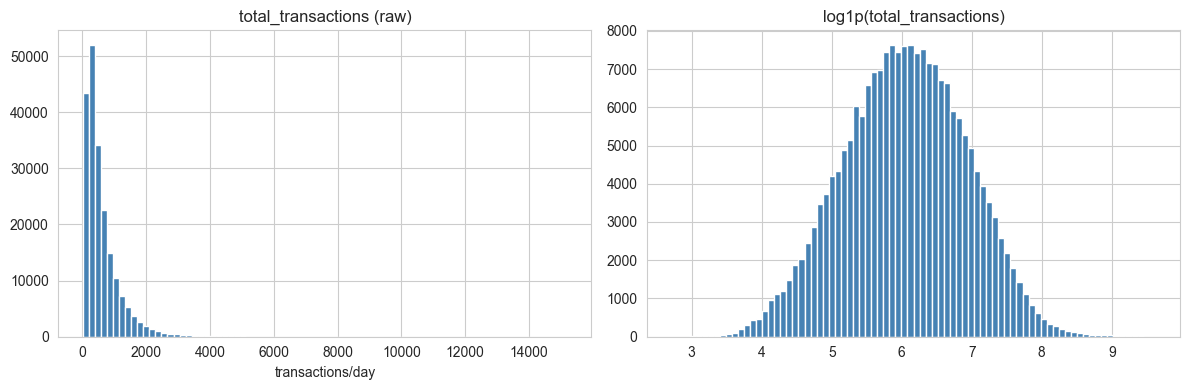

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(tx['total_transactions'], bins=80, color='steelblue')
ax[0].set_title('total_transactions (raw)')
ax[0].set_xlabel('transactions/day')
ax[1].hist(np.log1p(tx['total_transactions']), bins=80, color='steelblue')
ax[1].set_title('log1p(total_transactions)')
plt.tight_layout(); plt.savefig(ROOT / 'reports' / 'figures' / 'eda_demand_dist.png', dpi=120); plt.show()

## Estacionalidad semanal por formato

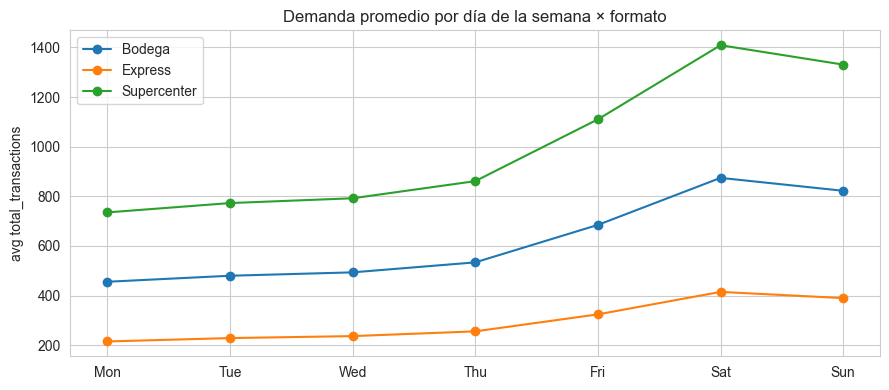

In [6]:
df = tx.merge(st, on='store_id').merge(cal, on='date')
agg = df.groupby(['store_format', 'day_of_week'])['total_transactions'].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4))
for fmt, sub in agg.groupby('store_format'):
    ax.plot(sub['day_of_week'], sub['total_transactions'], marker='o', label=fmt)
ax.set_xticks(range(7)); ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_ylabel('avg total_transactions'); ax.set_title('Demanda promedio por día de la semana × formato'); ax.legend()
plt.tight_layout(); plt.savefig(ROOT / 'reports' / 'figures' / 'eda_dow_format.png', dpi=120); plt.show()

Los Supercenters muestran el patrón semanal más fuerte (pico fin de semana). Express es más plano.

## Demanda diaria total — vista temporal

In [7]:
daily = df.groupby('date')['total_transactions'].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values)

from itertools import groupby as _groupby
from datetime import timedelta as _td

for col, label, color in [('is_buen_fin','Buen Fin','red'), ('is_navidad_season','Navidad','green'), ('is_semana_santa','Semana Santa','purple')]:
    evt_dates = sorted(cal[cal[col].fillna(False).astype(bool)]['date'])
    if not evt_dates:
        continue
    # Group into contiguous date blocks so wrapped seasons (e.g. navidad
    # Jan-1-6 AND Dec-15-Jan-6) are drawn as separate spans, not one giant span.
    blocks = []
    for _, g in _groupby(enumerate(evt_dates), lambda x: (x[1] - _td(days=x[0])).date()):
        block = [d for _, d in g]
        blocks.append((block[0], block[-1]))
    for i, (start, end) in enumerate(blocks):
        ax.axvspan(start, end, color=color, alpha=0.18,
                   label=label if i == 0 else None)

ax.set_title('Demanda diaria total (todas las tiendas y categorías)'); ax.legend()
plt.tight_layout(); plt.savefig(ROOT / 'reports' / 'figures' / 'eda_daily_total.png', dpi=120); plt.show()

## Resumen por categoría

In [8]:
cat_summary = tx.groupby('category').agg(
    rows=('total_transactions','size'),
    mean_tx=('total_transactions','mean'),
    median_tx=('total_transactions','median'),
    mean_units=('units_sold','mean'),
    cash_share=('amount_cash','mean'),
).round(2)
cat_summary

,rows,mean_tx,median_tx,mean_units,cash_share
category,,,,,
Abarrotes,33993,1184.14,979.0,2271.55,141411.74
Bebidas,33993,920.03,762.0,1764.95,65875.20
Cuidado_Personal,33993,591.41,492.0,1131.26,48533.47
Electronica,33993,197.39,163.0,377.96,46322.88
Hogar,33993,459.6,383.0,877.65,60256.14
Ropa,33993,328.5,273.0,628.67,67371.09


## Notas para feature engineering

1. Series suficientemente largas (425 días) para lags 1/7/14/28.
2. Estacionalidad semanal clara → lag-7 será un baseline fuerte.
3. Eventos (Buen Fin, Navidad) visibles → calendar flags como features.
4. Distribución de demanda con cola larga → considerar log o usar HGB (robusto a no-normalidad).